In [2]:
!pip install transformers datasets -q
print("Done")

Done


In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("All imports done")
print("GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else "CPU")

All imports done
GPU: True
Device: Tesla T4


In [4]:
dataset = load_dataset("imdb")
print(dataset)
print("\nSample:")
print(dataset["train"][0]["text"][:300])
print("Label:", dataset["train"][0]["label"])

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h
Label: 0


In [5]:
train_dataset = dataset["train"]\
    .shuffle(seed=42).select(range(2000))

val_dataset = dataset["test"]\
    .shuffle(seed=42).select(range(500))

test_dataset = dataset["test"]\
    .shuffle(seed=42).select(range(500, 1000))

print("Train size:", len(train_dataset))
print("Val size  :", len(val_dataset))
print("Test size :", len(test_dataset))

# Check distribution
print("\nTrain Labels:")
labels = train_dataset["label"]
print("Positive:", labels.count(1))
print("Negative:", labels.count(0))

Train size: 2000
Val size  : 500
Test size : 500

Train Labels:
Positive: 1000
Negative: 1000


In [6]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)
print("Tokenizer loaded")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded


In [7]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function, batched=True)
val_dataset = val_dataset.map(
    tokenize_function, batched=True)
test_dataset = test_dataset.map(
    tokenize_function, batched=True)

print("Tokenization done")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenization done


In [8]:
cols = ["input_ids", "attention_mask", "label"]

train_dataset.set_format(
    type="torch", columns=cols)
val_dataset.set_format(
    type="torch", columns=cols)
test_dataset.set_format(
    type="torch", columns=cols)

print("Format set successfully")
print("Sample keys:",
      list(train_dataset[0].keys()))

Format set successfully
Sample keys: ['label', 'input_ids', 'attention_mask']


In [9]:
model = AutoModelForSequenceClassification\
    .from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )
print("Model loaded")
print("Parameters:",
      sum(p.numel()
          for p in model.parameters()))

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded
Parameters: 109483778


In [10]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec  = recall_score(labels, preds)
    f1   = f1_score(labels, preds)

    return {
        "accuracy" : round(acc,  4),
        "precision": round(prec, 4),
        "recall"   : round(rec,  4),
        "f1"       : round(f1,   4)
    }

print("compute_metrics defined")

compute_metrics defined


In [11]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    fp16=True,
    logging_steps=100,
    load_best_model_at_end=True,
    report_to="none"
)
print("Training args defined")

Training args defined


In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)
print("Trainer ready")

Trainer ready


In [13]:
print("Training started...")
trainer.train()

Training started...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.591962,0.350825,0.854000,0.853100,0.849600,0.851300
2,0.325522,0.356550,0.858000,0.835200,0.886200,0.860000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=250, training_loss=0.4193488807678223, metrics={'train_runtime': 54.0026, 'train_samples_per_second': 74.071, 'train_steps_per_second': 4.629, 'total_flos': 263111055360000.0, 'train_loss': 0.4193488807678223, 'epoch': 2.0})

In [14]:
print("Evaluating...")
results = trainer.evaluate(test_dataset)

print("\n===== TEST RESULTS =====")
for key, val in results.items():
    print(f"{key}: {round(val, 4)}")

Evaluating...



===== TEST RESULTS =====
eval_loss: 0.3824
eval_accuracy: 0.84
eval_precision: 0.8403
eval_recall: 0.8264
eval_f1: 0.8333
eval_runtime: 0.9547
eval_samples_per_second: 523.71
eval_steps_per_second: 33.517
epoch: 2.0


In [15]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(
    predictions.predictions, axis=1)
y_true = predictions.label_ids

print("Unique predictions:", np.unique(y_pred))
print("Unique true labels:", np.unique(y_true))
print("Sample preds:", y_pred[:10])
print("Sample true :", y_true[:10])

Unique predictions: [0 1]
Unique true labels: [0 1]
Sample preds: [0 1 0 1 0 1 0 1 0 1]
Sample true : [0 1 0 1 1 0 0 1 0 1]


In [16]:
print("=" * 40)
print("BERT FINE-TUNING RESULTS")
print("=" * 40)
print("Accuracy :",
      round(accuracy_score(
          y_true, y_pred), 4))
print("Precision:",
      round(precision_score(
          y_true, y_pred), 4))
print("Recall   :",
      round(recall_score(
          y_true, y_pred), 4))
print("F1 Score :",
      round(f1_score(
          y_true, y_pred), 4))
print("=" * 40)

BERT FINE-TUNING RESULTS
Accuracy : 0.84
Precision: 0.8403
Recall   : 0.8264
F1 Score : 0.8333


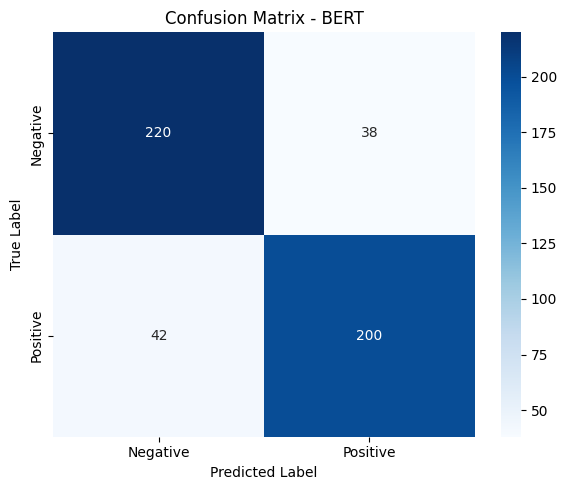

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BERT")
plt.tight_layout()
plt.show()